In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

pd.set_option('display.max_columns', None)

In [3]:
amr_matches = pd.read_csv("../data/ecoli/summary_matches.txt", sep="\t")
virulence_matches = pd.read_csv("../data/paeruginosa/summary_virulence.txt", sep="\t")
ec = pd.read_csv("../../PIBET/data/ecoli/ecoli_data_2023.tsv", sep="\t")

/tmp/ipykernel_6344/1697715911.py:1: DtypeWarning: Columns (35,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  amr_matches = pd.read_csv("../data/ecoli/summary_matches.txt", sep="\t")


In [4]:
def transform_amr_df(df):
    """
    Transforms an AMR category DataFrame into a binary matrix (0/1) indicating the presence of resistance genes.
    Adds an "MDR" column with 1 if three or more antibiotic classes (excluding "Efflux" and "ESBL (AmpC type)") have resistance.
    
    Parameters:
    df (pd.DataFrame): DataFrame with AMR categories as columns and resistance genes as values.
    
    Returns:
    pd.DataFrame: Transformed DataFrame with 0s and 1s, including an "MDR" column.
    """
    # Convert all values to string to handle NaN values correctly
    df_binary = df.iloc[:, 1:].notna().astype(int)
    
    # Add back the first two columns (sample identifiers)
    df_binary.insert(0, df.columns[0], df.iloc[:, 0])

    # Define antibiotic classes to exclude from MDR calculation
    excluded_classes = {"Efflux", "ESBL (AmpC type)", "Colistin", "Fosfomycin"}
    
    # Identify the relevant antibiotic classes for MDR classification
    relevant_columns = [col for col in df_binary.columns[1:] if col not in excluded_classes]

    # Compute MDR: If an isolate is resistant to 3 or more antibiotic classes, classify as MDR (1)
    df_binary["MDR"] = (df_binary[relevant_columns].sum(axis=1) >= 3).astype(int)

    return df_binary

In [5]:
amr = transform_amr_df(amr_matches)

In [6]:
def plot_amr_category_frequency(df_binary):
    """
    Plots the frequency of resistance presence by AMR category as a bar plot with a secondary axis.
    The "MDR" bar is highlighted with alpha = 0.5.
    
    Parameters:
    df_binary (pd.DataFrame): Binary AMR DataFrame with 0s and 1s.
    """
    # Summing across rows to get frequency per category
    amr_frequencies = df_binary.iloc[:, 1:].sum().sort_values(ascending=False)
    
    # Compute MDR frequency and proportion
    mdr_frequency = df_binary["MDR"].sum()
    mdr_proportion = mdr_frequency / df_binary.shape[0]
    print(f"MDR Frequency: {mdr_frequency}")
    print(f"MDR Proportion: {mdr_proportion:.4f}")

    carb_frequency = df_binary["Carbapenemase"].sum()
    carb_proportion = carb_frequency / df_binary.shape[0]
    print(f"Carb Frequency: {carb_frequency}")
    print(f"Carb Proportion: {carb_proportion:.4f}")

    # Plot setup
    fig, ax1 = plt.subplots(figsize=(12, 9))
    
    # Primary axis - Frequency
    bars = ax1.bar(amr_frequencies.index, amr_frequencies.values, color='steelblue', label='Frequency', alpha=0.6)
    ax1.set_xlabel("AMR Category")
    ax1.set_ylabel("Frequency")
    ax1.set_xticklabels(amr_frequencies.index, rotation=45, ha="right")
    
    
    # Apply alpha to MDR
    for i, category in enumerate(amr_frequencies.index):
        if category == "MDR":
            bars[i].set_alpha(1)
    
    plt.title("E. coli")
    plt.tight_layout()
    plt.savefig("../out/amr_ecoli.svg", format="svg", dpi=150)
    plt.savefig("../out/amr_ecoli.png", format="png", dpi=150)

    plt.show();

/tmp/ipykernel_6344/3732383908.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(amr_frequencies.index, rotation=45, ha="right")


MDR Frequency: 11532
MDR Proportion: 0.4656
Carb Frequency: 461
Carb Proportion: 0.0186


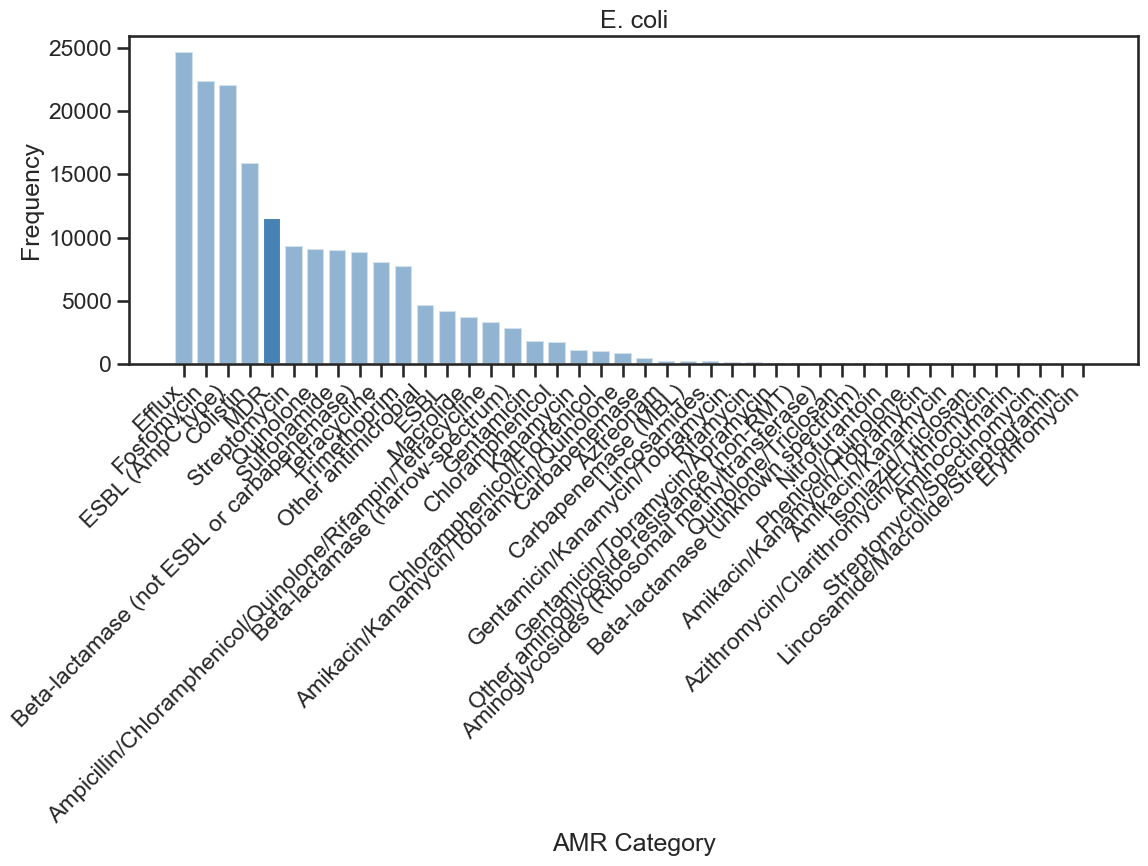

In [7]:
plot_amr_category_frequency(amr)

In [8]:
def get_mdr_combinations(df, mdr_column="MDR"):
    """
    Plots a heatmap showing the frequency of antibiotic resistance combinations leading to MDR.

    Parameters:
    df (pd.DataFrame): DataFrame containing binary resistance data for different antibiotic classes.
    mdr_column (str): The column name that indicates MDR status (default: "MDR").
    """
    if mdr_column not in df.columns:
        raise ValueError(f"Column '{mdr_column}' not found in dataframe.")

    # Identify non-antibiotic columns (assuming the first column is an identifier)
    non_antibiotic_cols = [df.columns[0], mdr_column]

    # Filter MDR-positive cases and drop non-antibiotic columns
    df_mdr = df[df[mdr_column] == 1].drop(columns=non_antibiotic_cols)

    if df_mdr.empty:
        raise ValueError("No MDR-positive cases found.")

    # Create a unique identifier for each resistance pattern
    df_mdr["Resistance Pattern"] = df_mdr.apply(lambda row: "-".join(row.astype(str)), axis=1)

    # Count the frequency of each unique resistance pattern
    pattern_counts = df_mdr["Resistance Pattern"].value_counts().reset_index()
    pattern_counts.columns = ["Resistance Pattern", "Frequency"]

    # Remove patterns that occur only once
    pattern_counts = pattern_counts[pattern_counts["Frequency"] > 1]

    # Split the resistance pattern back into individual antibiotic resistances
    pattern_expanded = pattern_counts["Resistance Pattern"].str.split("-", expand=True)
    pattern_expanded.columns = df_mdr.columns[:-1]  # Use original antibiotic column names
    pattern_expanded["Frequency"] = pattern_counts["Frequency"]

    # Convert to integer values
    for col in pattern_expanded.columns:
        pattern_expanded[col] = pd.to_numeric(pattern_expanded[col], errors="coerce").fillna(0).astype(int)

    # Convert into matrix form
    heatmap_data = pattern_expanded.set_index("Frequency").astype(int)
    
    # Transpose to have antibiotics on x-axis and patterns on y-axis
    heatmap_data = heatmap_data.T
    
    # Select only the first 50 columns
    heatmap_data = heatmap_data.iloc[:, :50]
    
    # Define the custom colormap (1 = blue, 0 = white)
    # Define the custom colormap (1 = steelblue, 0 = white)
    cmap = sns.color_palette([(1, 1, 1), (70/255, 130/255, 180/255)], as_cmap=True)

    # Plot the heatmap without annotations and without color bar
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")
    
    ax = sns.heatmap(heatmap_data, annot=False, cmap=cmap, linewidths=0.5, cbar=False)
    
    # Add custom legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="steelblue", edgecolor="steelblue", label="Presence"),
                       Patch(facecolor="white", edgecolor="black", label="Absence")]
    plt.legend(handles=legend_elements, loc="upper right", title="", facecolor="white", fontsize=16)
    
    plt.title("E. coli", fontsize=20)
    plt.xlabel("# Samples with the MDR Pattern", fontsize=16)
    plt.ylabel("Antibiotics", fontsize=16)
    plt.xticks(rotation=90, ha="right", fontsize=16)
    plt.yticks(rotation=0, fontsize=16)

    plt.savefig("../out/mdr_patterns_ecoli.svg", format="svg", dpi=150)
    plt.savefig("../out/mdr_patterns_ecoli.png", format="png", dpi=150)

    plt.show()
    
    return heatmap_data

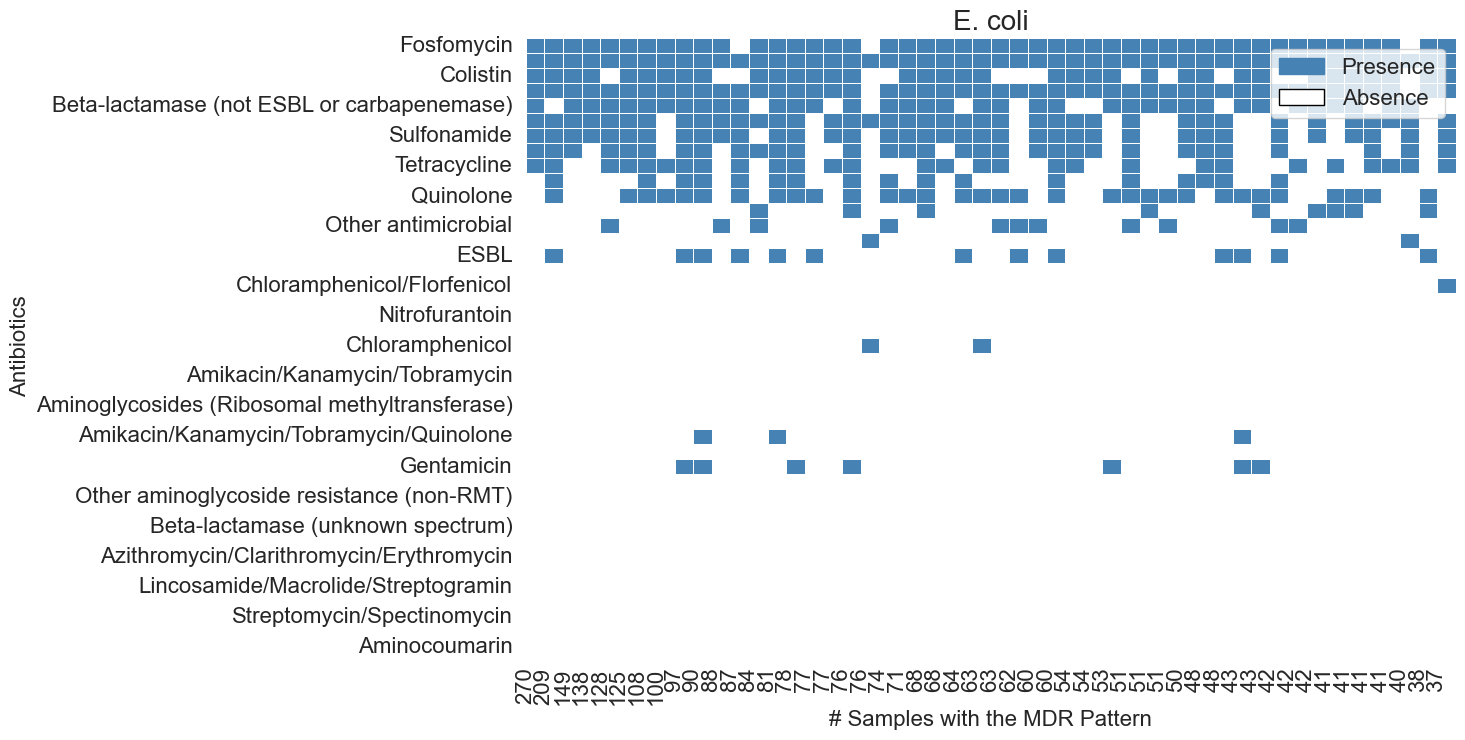

Frequency,270,209,149,138,128,125,108,100,97,90,88,87,84,81,78,77,77,76,76,74,71,68,68,64,63,63,62,60,60,54,54,53,51,51,51,50,48,48,43,43,42,42,42,41,41,41,41,40,38,37
Fosfomycin,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1
Efflux,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Colistin,1,1,1,1,0,1,1,1,1,1,0,0,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0,1,1,1,1,0,1,0,1,1,0,1,1,0,0,1,1,1,1,1,0,1,1
ESBL (AmpC type),1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1
Beta-lactamase (not ESBL or carbapenemase),1,0,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,1,0,1,1,1,1,0,1,1,0,1,1,0,0,1,1,1,1,1,1,0,1,1,0,1,1,1,1,0,1,1,0,0
Streptomycin,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,0,1,0,0,1,1,1,0,0,1,0,1,0,1,1,1,1,0,1
Sulfonamide,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1,0,1,1,0,1,1,1,1,1,1,1,0,1,1,1,1,0,1,0,0,1,1,1,0,0,1,0,1,0,1,1,0,1,0,1
Trimethoprim,1,1,1,0,1,1,1,0,1,1,0,1,1,1,1,0,0,1,0,1,1,1,0,1,1,1,0,1,1,1,1,0,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,1,0,1
Tetracycline,1,1,0,0,1,1,1,1,1,1,0,1,0,1,1,0,1,1,0,0,0,1,1,0,1,1,0,0,1,1,0,0,1,0,0,0,1,1,0,0,0,1,0,1,0,1,1,1,0,1
Macrolide,0,1,0,0,0,0,1,0,1,1,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0


In [9]:
get_mdr_combinations(amr)


# AMR score

In [11]:
def resistance_score(df):
    df_sub = df.copy()
    df_sub["resistance_score"] = 0

    # Explicit column names
    esbl_col = ["ESBL (AmpC type)", "Beta-lactamase (narrow-spectrum)", "ESBL", "Beta-lactamase (unknown spectrum)"]
    carbapenemase_cols = ["Carbapenemase", "Carbapenemase (MBL)"]
    colistin_col = "Colistin"

    # Score 3: Carbapenemase + Colistin resistance
    mask3 = df[carbapenemase_cols].notna().any(axis=1) & df[colistin_col].notna()
    df_sub.loc[mask3, 'resistance_score'] = 3

    # Score 2: Carbapenemase only
    mask2 = df[carbapenemase_cols].notna().any(axis=1) & df[colistin_col].isna() & (df_sub['resistance_score'] < 3)
    df_sub.loc[mask2, 'resistance_score'] = 2

    # Score 1: ESBL only
    mask1 = df[esbl_col].notna() & (~df[carbapenemase_cols].notna().any(axis=1)) & (df_sub['resistance_score'] < 2)
    df_sub.loc[mask1, 'resistance_score'] = 1

    # Score 0: none of the above (default)

    return df_sub[['resistance_score']]

## patients 

In [9]:
amr.rename(columns={"Isolate":"sampleid"}, inplace=True)

In [10]:
ec = ec.merge(amr, on="sampleid", how="left")

In [11]:
ec_patient = ec[pd.notna(ec['pat_id'])]

In [12]:
def plot_patient_samples_filtered(df, min_samples=5):
    """
    Plots patient samples with unique patient IDs on the y-axis, and each dot represents a sample.
    Samples are color-coded based on the total number of AMR classes.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing patient IDs, sample dates, and AMR data.
    min_samples (int): Minimum number of samples a patient must have to be included in the plot.
    """
    # Define the exact AMR columns
    amr_columns = [
        'Fosfomycin', 'Efflux', 'Colistin', 'ESBL (AmpC type)',
        'Beta-lactamase (not ESBL or carbapenemase)', 'Streptomycin',
        'Sulfonamide', 'Trimethoprim', 'Tetracycline', 'Macrolide', 'Quinolone',
        'Ampicillin/Chloramphenicol/Quinolone/Rifampin/Tetracycline',
        'Other antimicrobial', 'Beta-lactamase (narrow-spectrum)', 'ESBL',
        'Quinolone/Triclosan', 'Chloramphenicol/Florfenicol', 'Lincosamides',
        'Nitrofurantoin', 'Aztreonam', 'Chloramphenicol', 'Kanamycin',
        'Amikacin/Kanamycin/Tobramycin', 'Carbapenemase (MBL)',
        'Aminoglycosides (Ribosomal methyltransferase)', 'Rifamycin',
        'Amikacin/Kanamycin/Tobramycin/Quinolone', 'Carbapenemase',
        'Gentamicin', 'Gentamicin/Kanamycin/Tobramycin',
        'Other aminoglycoside resistance (non-RMT)',
        'Gentamicin/Tobramycin/Apramycin', 'Beta-lactamase (unknown spectrum)',
        'Amikacin/Kanamycin', 'Azithromycin/Clarithromycin/Erythromycin',
        'Isoniazid/Triclosan', 'Lincosamide/Macrolide/Streptogramin',
        'Phenicol/Quinolone', 'Streptomycin/Spectinomycin', 'Erythromycin',
        'Aminocoumarin'
    ]
    
    # Define the exact AMR columns
    amr_columns = [
        'Fosfomycin', 'Efflux', 'Colistin', 'ESBL (AmpC type)',
        'Beta-lactamase (not ESBL or carbapenemase)', 'Streptomycin',
        'Sulfonamide', 'Trimethoprim', 'Tetracycline', 'Macrolide', 'Quinolone',
        'Ampicillin/Chloramphenicol/Quinolone/Rifampin/Tetracycline',
        'Other antimicrobial', 'Beta-lactamase (narrow-spectrum)', 'ESBL',
        'Quinolone/Triclosan', 'Chloramphenicol/Florfenicol', 'Lincosamides',
        'Nitrofurantoin', 'Aztreonam', 'Chloramphenicol', 'Kanamycin',
        'Amikacin/Kanamycin/Tobramycin', 'Carbapenemase (MBL)',
        'Aminoglycosides (Ribosomal methyltransferase)', 'Rifamycin',
        'Amikacin/Kanamycin/Tobramycin/Quinolone', 'Carbapenemase',
        'Gentamicin', 'Gentamicin/Kanamycin/Tobramycin',
        'Other aminoglycoside resistance (non-RMT)',
        'Gentamicin/Tobramycin/Apramycin', 'Beta-lactamase (unknown spectrum)',
        'Amikacin/Kanamycin', 'Azithromycin/Clarithromycin/Erythromycin',
        'Isoniazid/Triclosan', 'Lincosamide/Macrolide/Streptogramin',
        'Phenicol/Quinolone', 'Streptomycin/Spectinomycin', 'Erythromycin',
        'Aminocoumarin'
    ]
    
    # Count samples per patient
    patient_counts = df["pat_id"].value_counts()

    # Filter patients with at least min_samples
    valid_patients = patient_counts[patient_counts >= min_samples].index
    df_filtered = df[df["pat_id"].isin(valid_patients)].copy()
    
    if df_filtered.empty:
        print(f"No patients with at least {min_samples} samples found.")
        return
    
    # Convert samplingdate to datetime
    df_filtered["samplingdate"] = pd.to_datetime(df_filtered["samplingdate"])

    # Sort by patient and date
    df_filtered = df_filtered.sort_values(by=["pat_id", "samplingdate"])

    # Calculate total AMR per sample
    df_filtered["Total_AMR"] = df_filtered[amr_columns].sum(axis=1)

    # Identify patients who start with AMR-negative and later develop AMR
    patients_to_plot = []
    for pat_id, group in df_filtered.groupby("pat_id"):
        if (group["Total_AMR"].iloc[0] == 0) and (group["Total_AMR"].sum() > 0):
            patients_to_plot.append(pat_id)
    
    # Filter dataset to include only those patients
    df_filtered = df_filtered[df_filtered["pat_id"].isin(patients_to_plot)]

    if df_filtered.empty:
        print("No patients found who transitioned from AMR-negative to AMR-positive.")
        return
    
    # Assign categorical codes for patient IDs
    df_filtered["pat_id"] = df_filtered["pat_id"].astype(str)
    df_filtered["y"] = df_filtered["pat_id"].astype("category").cat.codes

    # Melt the dataframe to plot each AMR class separately
    df_melted = df_filtered.melt(id_vars=["pat_id", "y", "samplingdate", "Total_AMR"], 
                                 value_vars=amr_columns, 
                                 var_name="AMR_Class", 
                                 value_name="Presence")
    
    # Separate positive and negative AMR cases
    df_negative = df_filtered[df_filtered["Total_AMR"] == 0]
    df_positive = df_melted[df_melted["Presence"] > 0]

    # Define evenly spaced x-ticks
    xticks = pd.date_range(start=df_filtered["samplingdate"].min(), 
                           end=df_filtered["samplingdate"].max(), 
                           freq="6M")

    # Plot
    plt.figure(figsize=(12, 10))

    # Plot AMR-negative samples (initial samples as black empty circles)
    plt.scatter(
        df_negative["samplingdate"], df_negative["y"],
        facecolors="none", edgecolors="black", s=100, linewidth=1.5, label="Initial AMR-Negative"
    )

    # Plot AMR-positive samples (highlighted in red)
    sns.scatterplot(
        data=df_positive,
        x="samplingdate",
        y="y",
        hue="AMR_Class",
        palette=["red"],  # All AMR-positive samples in red
        edgecolor="black",
        s=100  # Increased dot size
    )

    # Formatting the x-axis for even distribution
    plt.xticks(xticks, rotation=45)

    # Formatting
    plt.gca().set_yticks(df_filtered["y"].unique())
    plt.gca().set_yticklabels(df_filtered["pat_id"].unique())
    plt.xlabel("Sampling Date")
    plt.ylabel("Patient ID")
    plt.title(f"Patients Developing AMR Over Time (≥{min_samples} Samples)")
    
    # Customize legend
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=labels, title="AMR Class", facecolor="white")

    plt.grid(False)  # Remove grid for a cleaner look

    plt.show()

/tmp/ipykernel_5757/3894967172.py:100: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  xticks = pd.date_range(start=df_filtered["samplingdate"].min(),
/tmp/ipykernel_5757/3894967172.py:114: UserWarning: 
The palette list has fewer values (1) than needed (21) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


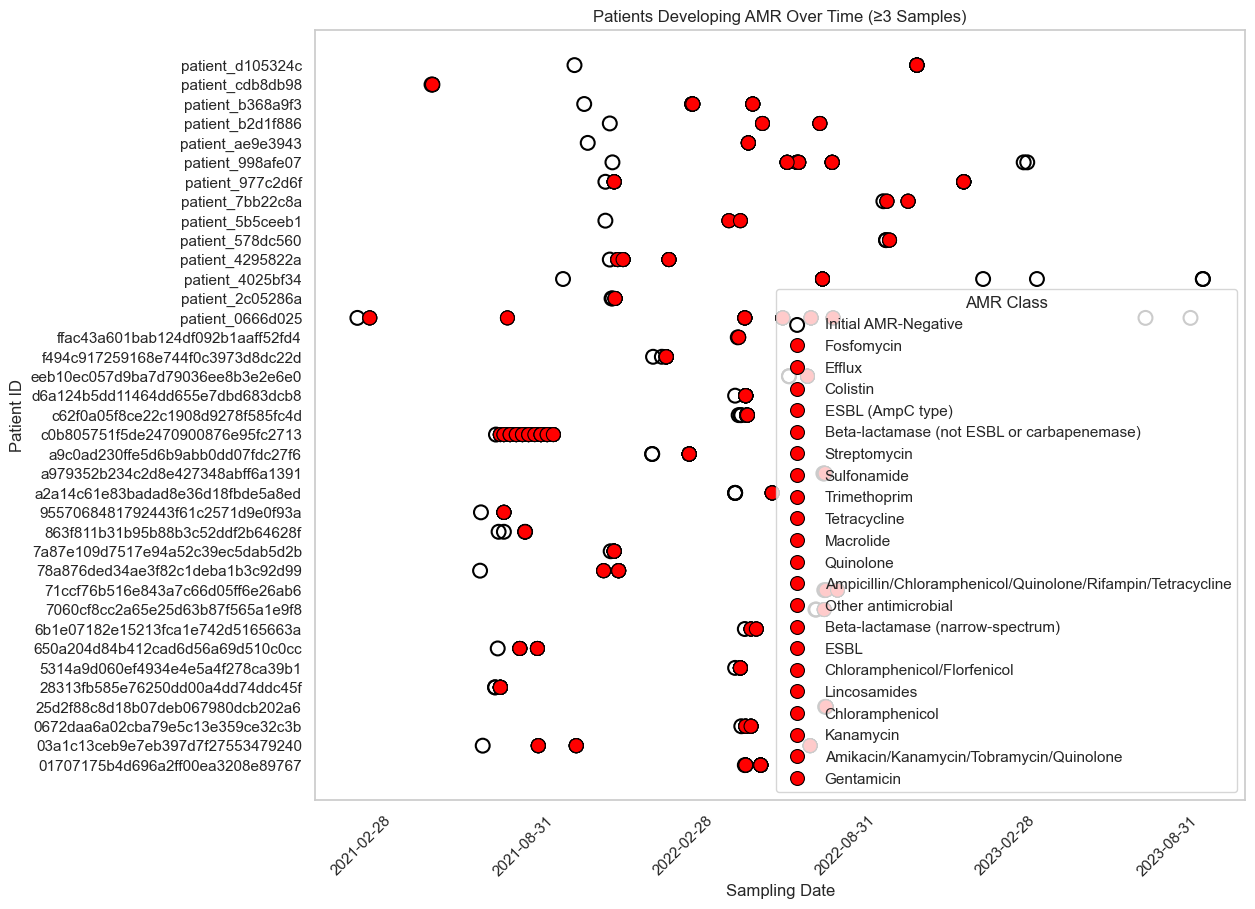

In [13]:
plot_patient_samples_filtered(ec_patient, min_samples=3)